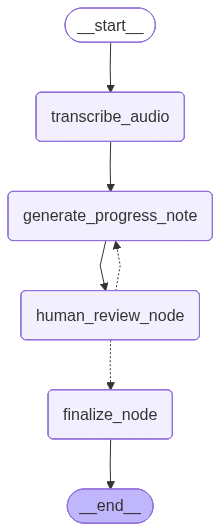

In [2]:

import os
import uuid
from typing import TypedDict,Optional,Literal
from pydantic import BaseModel
from pathlib import Path
from dotenv import load_dotenv

from langgraph.graph import StateGraph,START,END

from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate


class NDISProgressNote(BaseModel):
    subjective: str
    objective: str
    assessment: str
    plan: str
    linked_goals: list[str]=[]
    support_type: str
    participant_voice: str
    risks_incidents: str
    consent_noted: Optional[bool] = None

class AgentState(TypedDict):
    audio_path: Optional[str]
    transcript: str
    transcript_lines: list
    goals_context: str
    progress_note: Optional[NDISProgressNote]
    human_feedback: Optional[str]
    pdf_path: Optional[str]
    final_response: str


def transcribe_audio(state: AgentState) -> dict:
    audio_path = state.get("audio_path")
    if not audio_path: return {}

    import numpy as np
    import soundfile as sf
    import torch
    from faster_whisper import WhisperModel
    from pyannote.audio import Pipeline

    hf_token = state.get("hf_token") or os.environ.get("HF_TOKEN") or ""
    if not hf_token:
        raise RuntimeError("Missing HF_TOKEN (needed for pyannote diarization).")

    model = WhisperModel(state.get("whisper_model_size", "small"), device="cpu", compute_type="int8")
    segments, info = model.transcribe(audio_path, word_timestamps=True)
    segments = list(segments)

    def load_waveform(path):
        waveform, sample_rate = sf.read(path, always_2d=True)
        waveform = torch.from_numpy(np.asarray(waveform, dtype=np.float32).T)
        return {"waveform": waveform, "sample_rate": sample_rate}

    pipeline = Pipeline.from_pretrained("pyannote/speaker-diarization-3.1", token=hf_token)
    diarization = pipeline(load_waveform(audio_path))
    if hasattr(diarization, "speaker_diarization"):
        diarization = diarization.speaker_diarization

    turns = [(t.start, t.end, spk) for t, _, spk in diarization.itertracks(yield_label=True)]

    def assign_speaker(ws, we):
        best_speaker, best_overlap = None, 0.0
        for start, end, speaker in turns:
            overlap = max(0.0, min(we, end) - max(ws, start))
            if overlap > best_overlap:
                best_overlap, best_speaker = overlap, speaker
        return best_speaker or "UNKNOWN"

    lines, current_speaker, current_text, current_start = [], None, [], None
    for seg in segments:
        for w in (seg.words if seg.words else [None]):
            w_start, w_end, w_text = (w.start, w.end, w.word) if w else (seg.start, seg.end, seg.text)
            speaker = assign_speaker(w_start, w_end)
            if speaker != current_speaker:
                if current_text:
                    lines.append({
                        "speaker": current_speaker,
                        "start": float(current_start),
                        "text": "".join(current_text).strip(),
                    })
                current_speaker, current_text, current_start = speaker, [], w_start
            current_text.append(w_text)
    if current_text:
        lines.append({
            "speaker": current_speaker,
            "start": float(current_start),
            "text": "".join(current_text).strip(),
        })

    transcript_text = "\n".join(f"[{_format_timestamp(l['start'])}] {l['speaker']}: {l['text']}" for l in lines)

    def _to_native(value):
        if isinstance(value, (np.floating,)):
            return float(value)
        if isinstance(value, (np.integer,)):
            return int(value)
        return value

    lines = [{k: _to_native(v) for k, v in line.items()} for line in lines]

    return {"transcript": transcript_text, "transcript_lines": lines}

def generate_progress_note(state:AgentState):
    transcript=state.get("transcript","").strip()

    if not transcript:
        raise ValueError("Transcript is empty.")
    
    goals_context = state.get("goals_context", "No goals provided.")
    
    # transcript=validate_input(transcript)

    if not state.get("human_feedback"):
        prompt=ChatPromptTemplate.from_messages([
            ("system",sys_prompt),
            ("human",human_prompt)
        ])
        chain=prompt | model
        result=chain.invoke({"transcript":transcript,"goals_context":goals_context})
    else:
        prior=state.get("progress_note")
        result=model.invoke(
            revision_prompt.format(
                previous_note=prior.model_dump_json() if prior else "{}",
                feedback=state["human_feedback"]
            )
        )

    result_json=result.model_dump_json()
    # validated=validate_output(result_json)

    return {"progress_note":result}

def human_review_node(state:AgentState)->AgentState:
    note=state.get("progress_note")
    if not note:
        return {}
    
    feedback=interrupt({
        "note":note.model_dump(),
        "question":"Approve this NDIS Progress Note? Reply YES or provide correction."
    })
    if feedback.strip().lower() in ("ok","yes","approved","y"):
        return {"human_feedback":None}
    else:
        return {"human_feedback":feedback.strip()}
    

def finalize_node(state:AgentState)->AgentState:
    if state.get("human_feedback"):
        return {"final_response":"Pending further revision"}
    else:
        soap_data = state.get("progress_note")
        if not soap_data:
            return {"final_response": "Error: Note Missing"}

        pdf_path=OUTPUT_DIR/f"soap_{uuid.uuid4().hex}.pdf"
        soap_to_pdf(soap_data,pdf_path)

    return {
        "pdf_path": str(pdf_path),
         "final_response": "NDIS Progress Note approved and saved"}

def check_humanfb(state:AgentState)->Literal["generate_progress_note","finalize_node"]:
    if not state.get("human_feedback"):
        return "finalize_node"
    else:
        return "generate_progress_note"


graph=StateGraph(AgentState)


graph.add_node('transcribe_audio',transcribe_audio)
graph.add_node('generate_progress_note',generate_progress_note)
graph.add_node('human_review_node',human_review_node)
graph.add_node('finalize_node',finalize_node)

 
graph.add_edge(START,'transcribe_audio')
graph.add_edge('transcribe_audio','generate_progress_note')
graph.add_edge('generate_progress_note','human_review_node')
graph.add_conditional_edges('human_review_node',check_humanfb)
graph.add_edge("finalize_node",END)


workflow=graph.compile()
workflow

